In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed 
np.random.seed(42)

In [24]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
sns.set_palette("Spectral", n_colors=12)

sns.color_palette("Spectral", n_colors=12)


[(0.7803152633602461, 0.182160707420223, 0.2968089196462899),
 (0.8996539792387543, 0.340715109573241, 0.2848904267589389),
 (0.9679354094579008, 0.5074202229911572, 0.2996539792387543),
 (0.9923875432525952, 0.6938869665513263, 0.3900807381776239),
 (0.9954632833525567, 0.8476739715494039, 0.519261822376009),
 (0.9985390234525182, 0.9547097270280661, 0.6730488273740869),
 (0.9634755863129566, 0.9853902345251826, 0.6920415224913495),
 (0.8656670511341794, 0.9460207612456749, 0.6034602076124567),
 (0.6841983852364477, 0.8722029988465976, 0.6403690888119954),
 (0.48489042675893923, 0.7940023068050751, 0.6458285274894272),
 (0.30403690888119955, 0.6537485582468281, 0.6913494809688582),
 (0.24006151480199922, 0.47635524798154555, 0.7141868512110727)]

# 1. Handling the data

In [25]:
df = pd.read_csv('forPython_try2.csv', sep = ';', decimal = ',')
df.head()

,Time,Sample,cDC1,Macrophages,cDC2,Macrophages.1,cDC2.1,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils"
0,Before thawing,US,0%,0%,0%,0%,0%,0%,0%,0%,0%,"99,40%",0%,0%,0%
1,Before thawing,Pre-sort,"0,99%","0,18%","2,12%","5,28%","0,09%","1,95%","0,02%","8,41%","0,07%","9,06%","21,00%","7,23%","15,70%"
2,Before thawing,Sorted,"0,24%",0%,0%,0%,0%,"9,98E-05",0%,"0,03%","0,47%","66,50%","30,30%","0,06%","0,16%"
3,Day 0,After thawing,"0,20%","0,12%","1,60%","3,28%","0,04%","0,08%","0,28%","6,92%",0%,"5,12%","61,50%","0,12%","1,00%"
4,Day 0,US,0%,0%,0%,0%,0%,0%,0%,0%,0%,"99,70%",0%,0%,0%


In [26]:
# Drop columns where sample is US 
df = df[df['Sample'] != 'US']
df.head()

,Time,Sample,cDC1,Macrophages,cDC2,Macrophages.1,cDC2.1,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils"
1,Before thawing,Pre-sort,"0,99%","0,18%","2,12%","5,28%","0,09%","1,95%","0,02%","8,41%","0,07%","9,06%","21,00%","7,23%","15,70%"
2,Before thawing,Sorted,"0,24%",0%,0%,0%,0%,"9,98E-05",0%,"0,03%","0,47%","66,50%","30,30%","0,06%","0,16%"
3,Day 0,After thawing,"0,20%","0,12%","1,60%","3,28%","0,04%","0,08%","0,28%","6,92%",0%,"5,12%","61,50%","0,12%","1,00%"
6,Day 1,cDC1 no change,"0,57%","11,00%",0%,"3,55%","0,46%","0,11%",0%,"7,32%",0%,"3,78%","7,09%","0,34%","0,11%"
7,Day 1,cDC1 change everyday,"0,66%","9,96%",0%,"4,62%","0,41%","0,10%",0%,"8,18%",0%,"4,93%","8,38%","0,20%","0,56%"


In [27]:
df[df["Time"] == "Day 1"]

,Time,Sample,cDC1,Macrophages,cDC2,Macrophages.1,cDC2.1,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils"
6,Day 1,cDC1 no change,"0,57%","11,00%",0%,"3,55%","0,46%","0,11%",0%,"7,32%",0%,"3,78%","7,09%","0,34%","0,11%"
7,Day 1,cDC1 change everyday,"0,66%","9,96%",0%,"4,62%","0,41%","0,10%",0%,"8,18%",0%,"4,93%","8,38%","0,20%","0,56%"
8,Day 1,cDC1 change 1 of 2,"0,57%","11,00%",0%,"3,55%","0,46%","0,11%",0%,"7,32%",0%,"3,78%","7,09%","0,34%","0,11%"
9,Day 1,HSC no change,"0,24%","3,87%",0%,"3,55%","0,08%","0,08%",0%,"9,40%",0%,"5,21%","7,11%","0,08%","0,32%"
10,Day 1,HSC change everyday,"0,24%","3,87%",0%,"3,55%","0,08%","0,08%",0%,"9,40%",0%,"5,21%","7,11%","0,08%","0,32%"
11,Day 1,HSC change 1 of 2,"0,50%","3,52%",0%,"4,66%",0%,"0,13%",0%,"13,70%",0%,"4,91%","9,57%","0,06%","0,38%"


In [28]:
df_day1 = df[df["Time"] == "Day 1"]
df_day1_cDC1_nochange = df_day1[df_day1["Sample"] == "cDC1 no change"]
df_day1_cDC1_change_everyday = df_day1[df_day1["Sample"] == "cDC1 change eveyday"]
df_day1_HSC_nochange = df_day1[df_day1["Sample"] == "HSC no change"]
df_day1_HSC_change1of2 = df_day1[df_day1["Sample"] == "HSC change 1 of 2"]


# 2. Preprocessing

In [29]:
def split_by_day (dataframe):
    sample_days = {}
    for day in dataframe["Time"].unique():
        sample_days[day] = dataframe[dataframe["Time"] == day]
    return sample_days

In [30]:
def split_by_sample(df):
    sample_dict = {}
    for sample_name in df["Sample"].unique():
        sample_dict[sample_name] = df[df["Sample"] == sample_name]

    return sample_dict


In [31]:
results_by_day = split_by_day(df)

## DCP proportions

In [32]:
# Keep only the DCP proportions
dcp_proportions = df.pivot(index='Time', columns='Sample', values='DCPs')
dcp_proportions

Sample,After thawing,HSC change 1 of 2,HSC change everyday,HSC no change,Pre-sort,Sorted,cDC1 change 1 of 2,cDC1 change everyday,cDC1 no change
Time,,,,,,,,,
Before thawing,NaN,NaN,NaN,NaN,"21,00%","30,30%",NaN,NaN,NaN
Day 0,"61,50%",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day 1,NaN,"9,57%","7,11%","7,11%",NaN,NaN,"7,09%","8,38%","7,09%"
Day 2,NaN,"32,70%","24,40%","27,10%",NaN,NaN,"24,50%","18,60%","21,20%"
Day 3,NaN,"35,40%","28,10%","32,70%",NaN,NaN,"35,40%","40,10%","32,00%"
Day 4,NaN,"16,80%","18,00%","14,50%",NaN,NaN,"18,10%","18,10%","15,30%"
Day 5,NaN,"4,32%","4,31%","6,76%",NaN,NaN,"3,92%","7,38%","4,82%"
Day 6,NaN,"1,45%","2,49%","1,79%",NaN,NaN,"1,34%","2,47%","1,46%"


In [37]:
df_before_thawing = df[df["Time"] == "Before Thawing"]
df_day0 = df[df["Time"] == "Day 0"]

# Add df_day 0 after df_before thawing
df_1st_days = pd.concat([df_before_thawing, df_day0], ignore_index=True)

df_1st_days = df_1st_days.set_index("Sample")
df_1st_days

,Time,cDC1,Macrophages,cDC2,Macrophages.1,cDC2.1,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils"
Sample,,,,,,,,,,,,,,
After thawing,Day 0,"0,20%","0,12%","1,60%","3,28%","0,04%","0,08%","0,28%","6,92%",0%,"5,12%","61,50%","0,12%","1,00%"


In [38]:
dcp_proportions

Sample,After thawing,HSC change 1 of 2,HSC change everyday,HSC no change,Pre-sort,Sorted,cDC1 change 1 of 2,cDC1 change everyday,cDC1 no change
Time,,,,,,,,,
Before thawing,NaN,NaN,NaN,NaN,"21,00%","30,30%",NaN,NaN,NaN
Day 0,"61,50%",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day 1,NaN,"9,57%","7,11%","7,11%",NaN,NaN,"7,09%","8,38%","7,09%"
Day 2,NaN,"32,70%","24,40%","27,10%",NaN,NaN,"24,50%","18,60%","21,20%"
Day 3,NaN,"35,40%","28,10%","32,70%",NaN,NaN,"35,40%","40,10%","32,00%"
Day 4,NaN,"16,80%","18,00%","14,50%",NaN,NaN,"18,10%","18,10%","15,30%"
Day 5,NaN,"4,32%","4,31%","6,76%",NaN,NaN,"3,92%","7,38%","4,82%"
Day 6,NaN,"1,45%","2,49%","1,79%",NaN,NaN,"1,34%","2,47%","1,46%"


In [43]:
dcp_proportions.loc["Day 0"] = dcp_proportions.loc["Day 0", "After thawing"]
dcp_proportions

KeyError: 'After thawing'

In [40]:
dcp_proportions.drop(columns=["After thawing", 'Pre-sort', 'Sorted'], inplace=True)

In [41]:
dcp_proportions

Sample,HSC change 1 of 2,HSC change everyday,HSC no change,cDC1 change 1 of 2,cDC1 change everyday,cDC1 no change
Time,,,,,,
Before thawing,NaN,NaN,NaN,NaN,NaN,NaN
Day 0,NaN,NaN,NaN,NaN,NaN,NaN
Day 1,"9,57%","7,11%","7,11%","7,09%","8,38%","7,09%"
Day 2,"32,70%","24,40%","27,10%","24,50%","18,60%","21,20%"
Day 3,"35,40%","28,10%","32,70%","35,40%","40,10%","32,00%"
Day 4,"16,80%","18,00%","14,50%","18,10%","18,10%","15,30%"
Day 5,"4,32%","4,31%","6,76%","3,92%","7,38%","4,82%"
Day 6,"1,45%","2,49%","1,79%","1,34%","2,47%","1,46%"


# 3. Figures

## Proportion of cell types

TypeError: no numeric data to plot

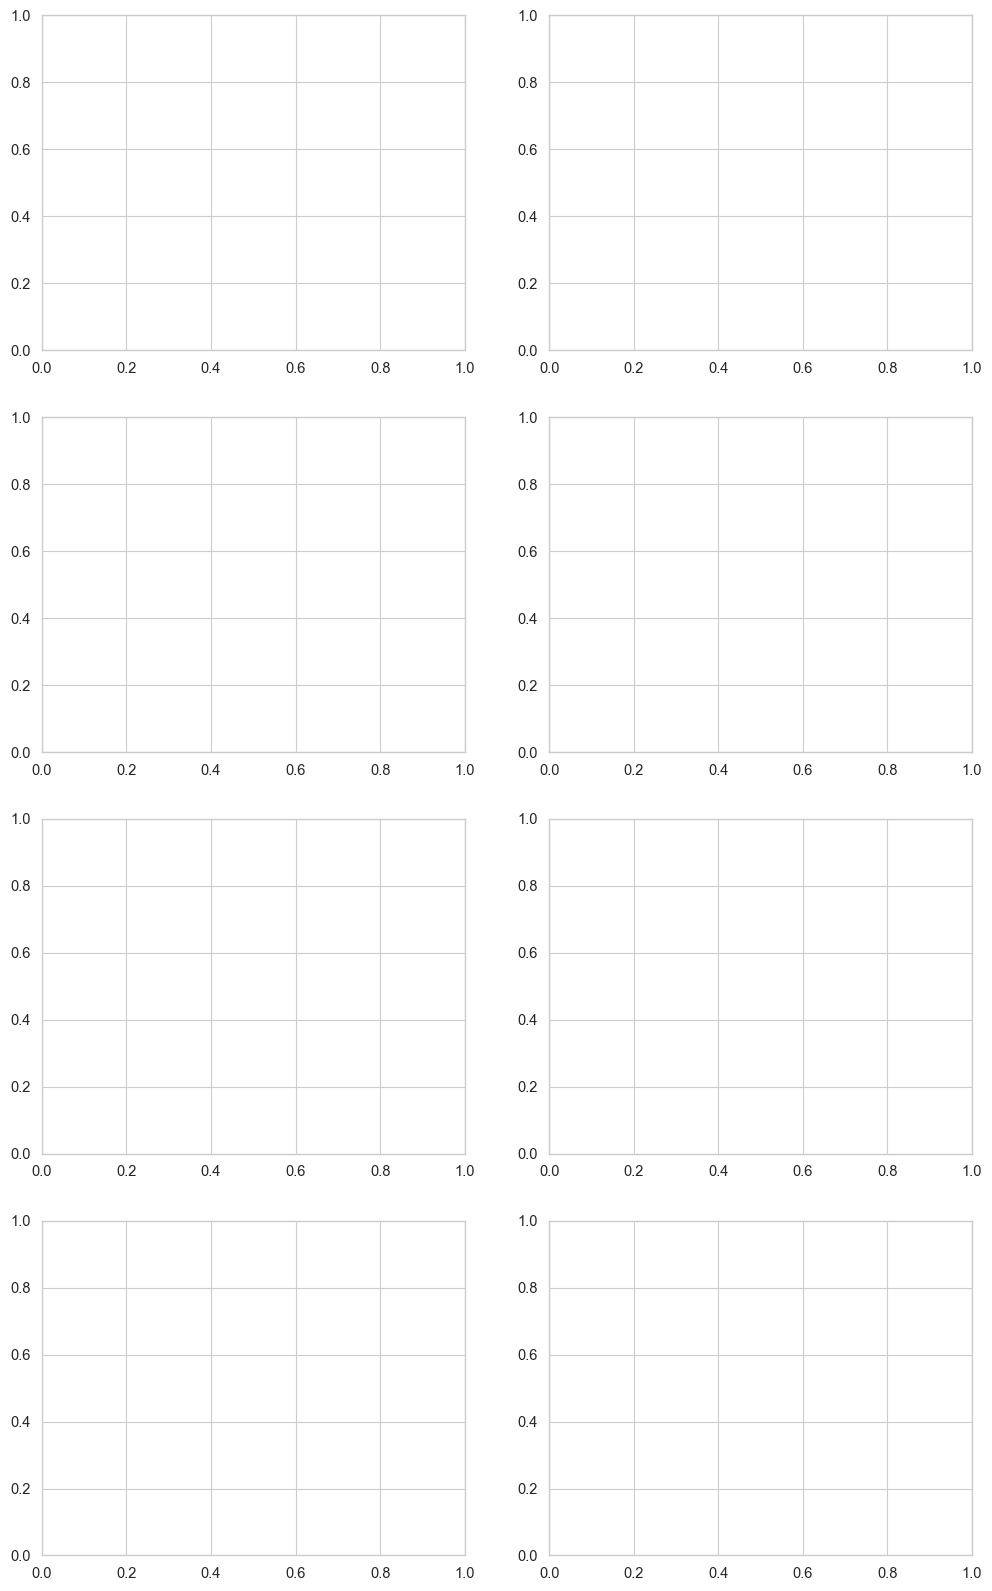

In [42]:
# Plot a figure with the 6 days with 3 lines and 2 columns
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 20))
days = list(results_by_day.keys())
for i, ax in enumerate(axes.flatten()):
    if i < len(days):
        day = days[i]
        day_data = results_by_day[day]
        day_proportions = pd.DataFrame()
        
        for sample_name, sample_data in split_by_sample(day_data).items():
            sample_proportions = sample_data.iloc[:, 2:].copy()
            sample_proportions.insert(0, "Sample", sample_name)
            day_proportions = pd.concat([day_proportions, sample_proportions], ignore_index=True)
        
        day_proportions_plot = day_proportions.melt(id_vars='Sample', var_name='Cell Type', value_name='Proportion')
        day_proportions_plot_pivot = day_proportions_plot.pivot(index='Sample', columns='Cell Type', values='Proportion')
        day_proportions_plot_pivot.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f'Cell Type Proportions for {day} Samples')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.legend_.remove()

plt.tight_layout()

plt.legend(
    loc='upper center',
    bbox_to_anchor=(-0.2, -0.5),
    ncol =6,
    frameon=False
)
plt.savefig('Figures/DCP_proportions_across_days.png', dpi=300, bbox_inches='tight')
plt.show()

## DCP proportions

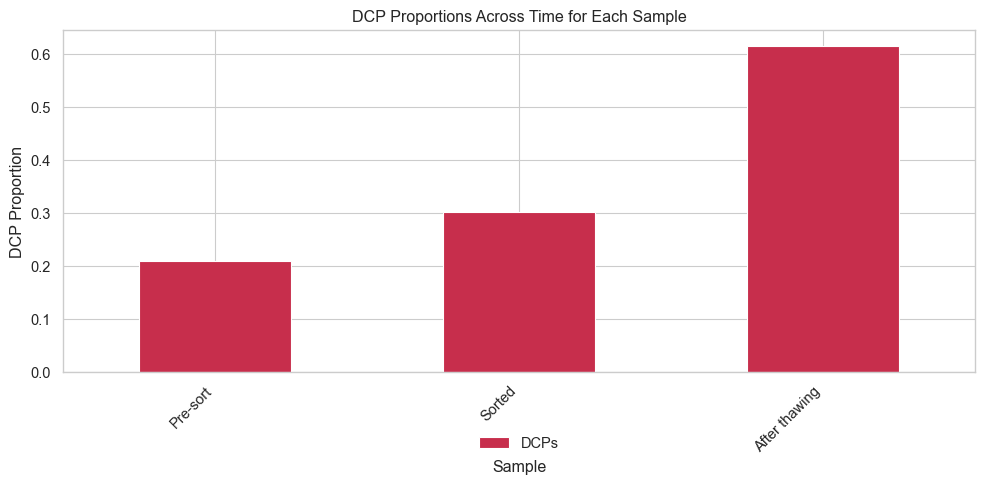

In [ ]:
# Plot bar chart of DCP proportions on first days
df_1st_days["DCPs"].plot(kind='bar', figsize=(10,5))
plt.title('DCP Proportions Across Time for Each Sample')
plt.xlabel('Sample')
plt.ylabel('DCP Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol =6,
    frameon=False
)
plt.tight_layout()
plt.show()  

<Figure size 1000x600 with 0 Axes>

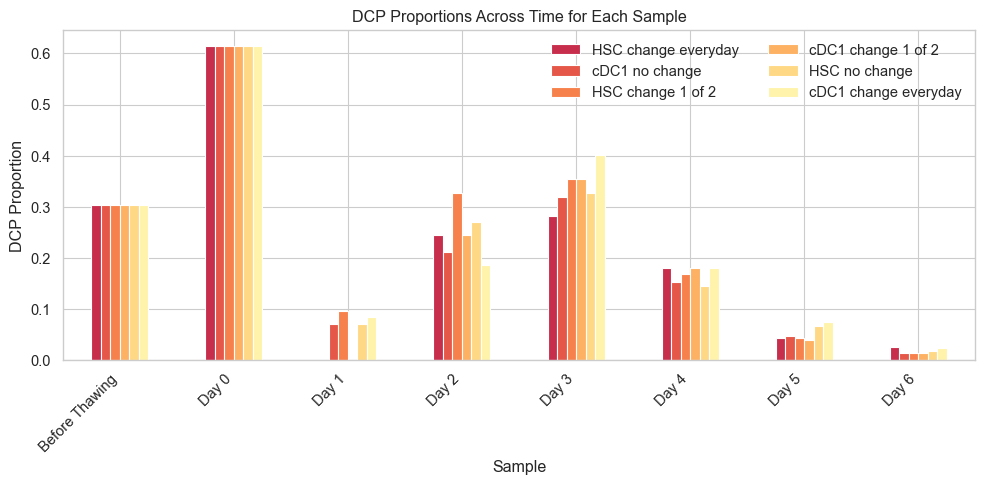

In [ ]:
# Plot bar chart of DCP proportions across time for each sample
plt.figure(figsize=(10, 6))
dcp_proportions.plot(kind='bar', figsize=(10,5))
plt.title('DCP Proportions Across Time for Each Sample')
plt.xlabel('Sample')
plt.ylabel('DCP Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title="", frameon=False, ncol=2)
plt.tight_layout()
plt.show()  